In [1]:
!pip install pandas numpy krippendorff matplotlib

In [2]:
import pandas as pd
import numpy as np
import krippendorff
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
# ---------------------------------------------------------------------
# 1. Загрузка данных
# ---------------------------------------------------------------------
model_files = {
    'yandex':   'annotations_df_yandex.csv',
    'qwen':     'annotations_df_qwen.csv',
    'mistral':  'annotations_df_mistral.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
    'gigachat': 'annotations_df_gigachat.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Оставляем только нужные столбцы
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type', 'subtype']
df_all = df_all[cols]

# Удаляем возможные дубликаты
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

In [4]:
# ---------------------------------------------------------------------
# 2. Сводные таблицы
# ---------------------------------------------------------------------
pivot_cog = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='cognitive_type',
    aggfunc='first'
)

pivot_sub = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='subtype',
    aggfunc='first'
)

In [5]:
# ---------------------------------------------------------------------
# 3. Преобразование в числовую матрицу
# ---------------------------------------------------------------------
def encode_matrix(df_pivot):
    """Преобразует DataFrame со строковыми категориями в числовую numpy-матрицу"""
    all_values = []
    for col in df_pivot.columns:
        valid_values = df_pivot[col].dropna().unique()
        all_values.extend(valid_values)

    le = LabelEncoder()
    le.fit(list(set(all_values)))

    matrix = np.full(df_pivot.shape, np.nan, dtype=float)

    for i, col in enumerate(df_pivot.columns):
        mask = df_pivot[col].notna()
        if mask.any():
            matrix[mask, i] = le.transform(df_pivot.loc[mask, col])

    return matrix

cog_matrix = encode_matrix(pivot_cog)
sub_matrix = encode_matrix(pivot_sub)

# Убираем строки, где все NaN
cog_matrix = cog_matrix[~np.all(np.isnan(cog_matrix), axis=1)]
sub_matrix = sub_matrix[~np.all(np.isnan(sub_matrix), axis=1)]

print(f"Матрица cognitive_type: {cog_matrix.shape[0]} единиц × {cog_matrix.shape[1]} моделей")
print(f"Матрица subtype: {sub_matrix.shape[0]} единиц × {sub_matrix.shape[1]} моделей")

Матрица cognitive_type: 189589 единиц × 5 моделей
Матрица subtype: 189589 единиц × 5 моделей


In [6]:
# ---------------------------------------------------------------------
# 4. Функция для бутстрепа вручную
# ---------------------------------------------------------------------
def krippendorff_alpha_with_ci(reliability_data, level_of_measurement='nominal',
                               n_bootstrap=1000, seed=42):
    """
    Вычисляет alpha и 95% доверительный интервал через бутстреп.
    """
    # Основной расчет
    alpha_val = krippendorff.alpha(reliability_data, level_of_measurement=level_of_measurement)

    # Бутстреп для доверительного интервала
    np.random.seed(seed)
    n_units = reliability_data.shape[0]
    bootstrap_alphas = []

    for i in range(n_bootstrap):
        # Случайная выборка единиц анализа с возвращением
        indices = np.random.choice(n_units, size=n_units, replace=True)
        bootstrap_sample = reliability_data[indices, :]

        try:
            boot_alpha = krippendorff.alpha(bootstrap_sample,
                                            level_of_measurement=level_of_measurement)
            if not np.isnan(boot_alpha):
                bootstrap_alphas.append(boot_alpha)
        except:
            continue

        # Прогресс-бар для длинных расчетов
        if (i + 1) % 100 == 0:
            print(f"  Бутстреп: {i+1}/{n_bootstrap}")

    if len(bootstrap_alphas) > 0:
        ci_lower = np.percentile(bootstrap_alphas, 2.5)
        ci_upper = np.percentile(bootstrap_alphas, 97.5)
    else:
        ci_lower, ci_upper = np.nan, np.nan

    return alpha_val, (ci_lower, ci_upper)

In [7]:
# ---------------------------------------------------------------------
# 5. Расчет с выборкой для скорости (опционально)
# ---------------------------------------------------------------------
# Если данных очень много (>10000 единиц), можно использовать подвыборку
# для ускорения бутстрепа
USE_SUBSAMPLE = True if cog_matrix.shape[0] > 10000 else False
SUBSAMPLE_SIZE = 10000

if USE_SUBSAMPLE:
    print(f"\n⚠️  Данных много ({cog_matrix.shape[0]} единиц).")
    print(f"   Использую случайную подвыборку из {SUBSAMPLE_SIZE} единиц для бутстрепа.")

    np.random.seed(42)
    sample_idx = np.random.choice(cog_matrix.shape[0], size=min(SUBSAMPLE_SIZE, cog_matrix.shape[0]), replace=False)

    cog_matrix_sample = cog_matrix[sample_idx, :]
    sub_matrix_sample = sub_matrix[sample_idx, :]
else:
    cog_matrix_sample = cog_matrix
    sub_matrix_sample = sub_matrix

print("\nСчитаем alpha для cognitive_type …")
alpha_cog, ci_cog = krippendorff_alpha_with_ci(cog_matrix_sample, n_bootstrap=500)

print("\nСчитаем alpha для subtype …")
alpha_sub, ci_sub = krippendorff_alpha_with_ci(sub_matrix_sample, n_bootstrap=500)

print(f"\nCognitive type alpha = {alpha_cog:.4f}  (95% CI: {ci_cog[0]:.4f} – {ci_cog[1]:.4f})")
print(f"Subtype alpha        = {alpha_sub:.4f}  (95% CI: {ci_sub[0]:.4f} – {ci_sub[1]:.4f})")


⚠️  Данных много (189589 единиц).
   Использую случайную подвыборку из 10000 единиц для бутстрепа.

Считаем alpha для cognitive_type …
  Бутстреп: 100/500
  Бутстреп: 200/500
  Бутстреп: 300/500
  Бутстреп: 400/500
  Бутстреп: 500/500

Считаем alpha для subtype …
  Бутстреп: 100/500
  Бутстреп: 200/500
  Бутстреп: 300/500
  Бутстреп: 400/500
  Бутстреп: 500/500

Cognitive type alpha = 0.0120  (95% CI: 0.0109 – 0.0132)
Subtype alpha        = 0.0073  (95% CI: 0.0070 – 0.0078)


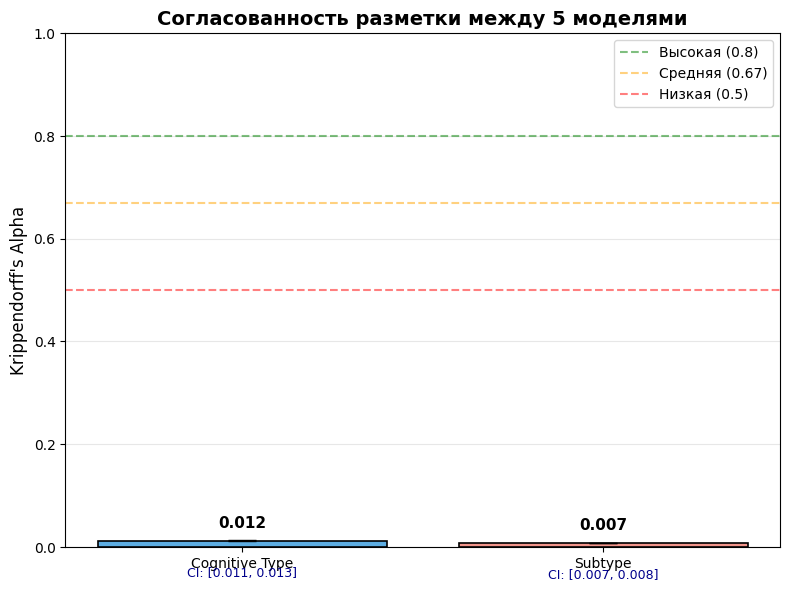

In [8]:
# ---------------------------------------------------------------------
# 6. Визуализация
# ---------------------------------------------------------------------
labels = ['Cognitive Type', 'Subtype']
alphas = [alpha_cog, alpha_sub]

# Формируем ошибки для bar chart
if not np.isnan(ci_cog[0]) and not np.isnan(ci_sub[0]):
    yerr = np.array([
        [alpha_cog - ci_cog[0], ci_cog[1] - alpha_cog],
        [alpha_sub - ci_sub[0], ci_sub[1] - alpha_sub]
    ]).T
else:
    yerr = None

fig, ax = plt.subplots(figsize=(8, 6))

if yerr is not None:
    bars = ax.bar(labels, alphas, yerr=yerr, capsize=10,
                  color=['#5DADE2', '#F1948A'], edgecolor='black', linewidth=1.2)
else:
    bars = ax.bar(labels, alphas, color=['#5DADE2', '#F1948A'],
                  edgecolor='black', linewidth=1.2)

ax.set_ylabel("Krippendorff's Alpha", fontsize=12)
ax.set_title("Согласованность разметки между 5 моделями", fontsize=14, fontweight='bold')
ax.set_ylim(0, max(1.0, max(alphas) + 0.15))

# Добавляем интерпретационные линии
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, linewidth=1.5, label='Высокая (0.8)')
ax.axhline(y=0.67, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='Средняя (0.67)')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Низкая (0.5)')

ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Подписываем значения над столбцами
for bar, val, ci in zip(bars, alphas, [ci_cog, ci_sub]):
    if not np.isnan(val):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
        if not np.isnan(ci[0]):
            ax.text(bar.get_x() + bar.get_width()/2., height - 0.05,
                    f'CI: [{ci[0]:.3f}, {ci[1]:.3f}]',
                    ha='center', va='top', fontsize=9, color='darkblue')

plt.tight_layout()
plt.savefig('krippendorff_alpha_bars.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('krippendorff_alpha_bars.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# ---------------------------------------------------------------------
# 7. Дополнительная диагностика
# ---------------------------------------------------------------------
print("\n" + "="*50)
print("ДИАГНОСТИКА:")
print(f"Количество единиц анализа (cognitive_type): {cog_matrix.shape[0]}")
print(f"Количество единиц анализа (subtype): {sub_matrix.shape[0]}")

# Проверяем, сколько моделей дали разметку для каждой единицы
print(f"\nСреднее количество моделей с разметкой (cognitive_type): "
      f"{np.mean(np.sum(~np.isnan(cog_matrix), axis=1)):.1f}")
print(f"Среднее количество моделей с разметкой (subtype): "
      f"{np.mean(np.sum(~np.isnan(sub_matrix), axis=1)):.1f}")

# Количество уникальных категорий
cog_cats = len(np.unique(cog_matrix[~np.isnan(cog_matrix)]))
sub_cats = len(np.unique(sub_matrix[~np.isnan(sub_matrix)]))
print(f"\nКоличество уникальных категорий cognitive_type: {cog_cats}")
print(f"Количество уникальных категорий subtype: {sub_cats}")

# Распределение количества моделей с разметкой
print("\nРаспределение количества моделей, давших разметку (cognitive_type):")
models_per_unit = np.sum(~np.isnan(cog_matrix), axis=1)
unique, counts = np.unique(models_per_unit, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {int(u)} моделей: {c} единиц ({c/len(models_per_unit)*100:.1f}%)")

# Интерпретация результатов
print("\n" + "="*50)
print("ИНТЕРПРЕТАЦИЯ:")
for name, alpha in zip(['Cognitive Type', 'Subtype'], [alpha_cog, alpha_sub]):
    if alpha >= 0.8:
        level = "высокая"
    elif alpha >= 0.67:
        level = "средняя"
    elif alpha >= 0.5:
        level = "умеренная"
    else:
        level = "низкая"
    print(f"{name}: {alpha:.3f} - {level} согласованность")


ДИАГНОСТИКА:
Количество единиц анализа (cognitive_type): 189589
Количество единиц анализа (subtype): 189589

Среднее количество моделей с разметкой (cognitive_type): 5.0
Среднее количество моделей с разметкой (subtype): 5.0

Количество уникальных категорий cognitive_type: 9
Количество уникальных категорий subtype: 42

Распределение количества моделей, давших разметку (cognitive_type):
  4 моделей: 553 единиц (0.3%)
  5 моделей: 189036 единиц (99.7%)

ИНТЕРПРЕТАЦИЯ:
Cognitive Type: 0.012 - низкая согласованность
Subtype: 0.007 - низкая согласованность


In [10]:
import pandas as pd
import numpy as np
import krippendorff
import matplotlib.pyplot as plt
from itertools import combinations

In [11]:
# ---------------------------------------------------------------------
# 1. Загрузка данных
# ---------------------------------------------------------------------
model_files = {
    'yandex':   'annotations_df_yandex.csv',
    'qwen':     'annotations_df_qwen.csv',
    'mistral':  'annotations_df_mistral.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
    'gigachat': 'annotations_df_gigachat.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type', 'subtype']
df_all = df_all[cols]
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

In [12]:
# ---------------------------------------------------------------------
# 2. Сводные таблицы и фильтрация ТОЛЬКО полных случаев
# ---------------------------------------------------------------------
pivot_cog = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='cognitive_type',
    aggfunc='first'
)

pivot_sub = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='subtype',
    aggfunc='first'
)

# Оставляем ТОЛЬКО строки, где все 5 моделей дали разметку (нет пропусков)
complete_cog = pivot_cog.dropna()
complete_sub = pivot_sub.dropna()

print("="*60)
print("АНАЛИЗ ТОЛЬКО ПОЛНЫХ СЛУЧАЕВ (без пропусков)")
print("="*60)
print(f"Всего единиц анализа: {len(pivot_cog)}")
print(f"Полные случаи cognitive_type: {len(complete_cog)} ({len(complete_cog)/len(pivot_cog)*100:.1f}%)")
print(f"Полные случаи subtype: {len(complete_sub)} ({len(complete_sub)/len(pivot_sub)*100:.1f}%)")

if len(complete_cog) < 2:
    print("\n❌ Слишком мало полных случаев для расчета alpha!")
    print("Модели практически не пересекаются в разметке.")
    print("Нужно либо ослабить критерий совпадения (например, сравнивать только по image_id),")
    print("либо признать, что модели работают с разными наборами данных.")
    exit()

АНАЛИЗ ТОЛЬКО ПОЛНЫХ СЛУЧАЕВ (без пропусков)
Всего единиц анализа: 189589
Полные случаи cognitive_type: 189036 (99.7%)
Полные случаи subtype: 189036 (99.7%)


In [13]:
# ---------------------------------------------------------------------
# 3. Функция для кодирования категорий в числа
# ---------------------------------------------------------------------
def encode_categorical_matrix(df):
    """
    Преобразует DataFrame с категориями в числовую матрицу.
    Все строки полные (без NaN).
    """
    # Собираем все уникальные значения из всех столбцов
    all_values = pd.unique(df.values.ravel())

    # Создаем mapping: категория -> число
    cat_to_num = {cat: i for i, cat in enumerate(all_values)}

    # Применяем mapping
    matrix = np.zeros(df.shape, dtype=float)
    for col_idx, col in enumerate(df.columns):
        matrix[:, col_idx] = [cat_to_num[val] for val in df[col]]

    return matrix

In [14]:
# ---------------------------------------------------------------------
# 4. Расчет Krippendorff's alpha
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ ДЛЯ ВСЕХ 5 МОДЕЛЕЙ")
print("="*60)

# Cognitive type
matrix_cog = encode_categorical_matrix(complete_cog)
alpha_cog = krippendorff.alpha(matrix_cog, level_of_measurement='nominal')
print(f"\nCognitive Type Alpha: {alpha_cog:.4f}")

# Subtype
matrix_sub = encode_categorical_matrix(complete_sub)
alpha_sub = krippendorff.alpha(matrix_sub, level_of_measurement='nominal')
print(f"Subtype Alpha: {alpha_sub:.4f}")


РЕЗУЛЬТАТЫ ДЛЯ ВСЕХ 5 МОДЕЛЕЙ

Cognitive Type Alpha: 0.0115
Subtype Alpha: 0.0071


In [15]:
# ---------------------------------------------------------------------
# 5. Простой процент согласия (для сравнения)
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("ПРОЦЕНТ ПОЛНОГО СОГЛАСИЯ")
print("="*60)

# Cognitive type
agreements_cog = 0
for idx, row in complete_cog.iterrows():
    if len(set(row)) == 1:  # все 5 значений одинаковые
        agreements_cog += 1

pct_cog = agreements_cog / len(complete_cog) * 100
print(f"\nCognitive Type:")
print(f"  Полное согласие (5/5): {agreements_cog}/{len(complete_cog)} = {pct_cog:.1f}%")

# Subtype
agreements_sub = 0
for idx, row in complete_sub.iterrows():
    if len(set(row)) == 1:
        agreements_sub += 1

pct_sub = agreements_sub / len(complete_sub) * 100
print(f"\nSubtype:")
print(f"  Полное согласие (5/5): {agreements_sub}/{len(complete_sub)} = {pct_sub:.1f}%")


ПРОЦЕНТ ПОЛНОГО СОГЛАСИЯ

Cognitive Type:
  Полное согласие (5/5): 139726/189036 = 73.9%

Subtype:
  Полное согласие (5/5): 54141/189036 = 28.6%


In [16]:
# ---------------------------------------------------------------------
# 6. Попарное согласие (процент совпадений)
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("ПОПАРНОЕ СОГЛАСИЕ (cognitive_type)")
print("="*60)

models = complete_cog.columns.tolist()
pair_agreements = []

for m1, m2 in combinations(models, 2):
    agreement = (complete_cog[m1] == complete_cog[m2]).mean() * 100
    pair_agreements.append({
        'model1': m1,
        'model2': m2,
        'agreement': agreement
    })
    print(f"{m1:12s} vs {m2:12s}: {agreement:.1f}%")


ПОПАРНОЕ СОГЛАСИЕ (cognitive_type)
gigachat     vs gpt-oss     : 82.6%
gigachat     vs mistral     : 86.2%
gigachat     vs qwen        : 86.1%
gigachat     vs yandex      : 84.5%
gpt-oss      vs mistral     : 89.8%
gpt-oss      vs qwen        : 89.7%
gpt-oss      vs yandex      : 86.9%
mistral      vs qwen        : 92.5%
mistral      vs yandex      : 88.5%
qwen         vs yandex      : 90.2%


In [17]:
# ---------------------------------------------------------------------
# 7. Анализ: какие модели чаще согласны
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("СРЕДНЕЕ СОГЛАСИЕ КАЖДОЙ МОДЕЛИ С ОСТАЛЬНЫМИ (cognitive_type)")
print("="*60)

for model in models:
    other_models = [m for m in models if m != model]
    agreements = []
    for other in other_models:
        agreements.append((complete_cog[model] == complete_cog[other]).mean() * 100)
    avg_agreement = np.mean(agreements)
    print(f"{model:12s}: {avg_agreement:.1f}%")


СРЕДНЕЕ СОГЛАСИЕ КАЖДОЙ МОДЕЛИ С ОСТАЛЬНЫМИ (cognitive_type)
gigachat    : 84.8%
gpt-oss     : 87.2%
mistral     : 89.3%
qwen        : 89.6%
yandex      : 87.5%


In [18]:
# ---------------------------------------------------------------------
# 8. Какие категории вызывают разногласия
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ ПО МОДЕЛЯМ")
print("="*60)

for col in complete_cog.columns:
    print(f"\n{col}:")
    value_counts = complete_cog[col].value_counts()
    for val, count in value_counts.items():
        print(f"  {val}: {count} ({count/len(complete_cog)*100:.1f}%)")


РАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ ПО МОДЕЛЯМ

gigachat:
  perceptual: 140078 (74.1%)
  interpretive: 48958 (25.9%)

gpt-oss:
  perceptual: 146274 (77.4%)
  interpretive: 42762 (22.6%)

mistral:
  perceptual: 143728 (76.0%)
  interpretive: 45224 (23.9%)
  unknown: 79 (0.0%)
  item: 3 (0.0%)
  perceptial: 2 (0.0%)

qwen:
  perceptual: 148856 (78.7%)
  interpretive: 40180 (21.3%)

yandex:
  perceptual: 164160 (86.8%)
  interpretive: 24694 (13.1%)
  spatial: 148 (0.1%)
  action: 30 (0.0%)
  perceptive: 4 (0.0%)


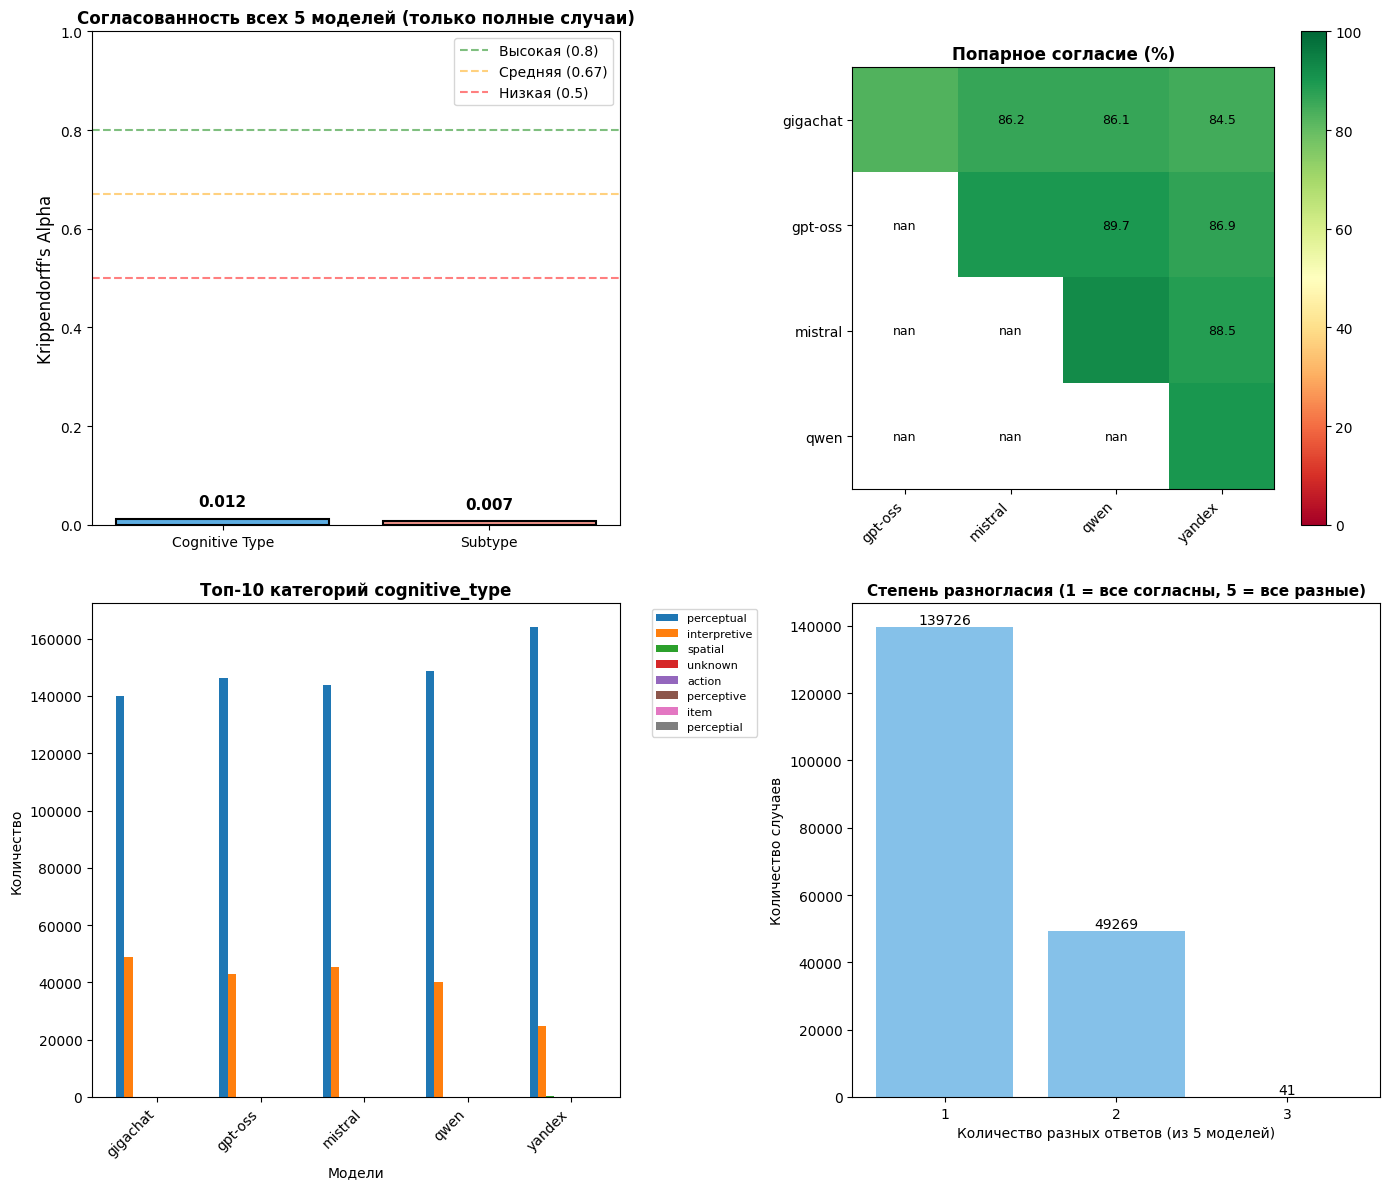

In [19]:
# ---------------------------------------------------------------------
# 9. Визуализация
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# График 1: Bar chart alpha
ax = axes[0, 0]
alphas = [alpha_cog, alpha_sub]
labels = ['Cognitive Type', 'Subtype']
colors = ['#5DADE2', '#F1948A']
bars = ax.bar(labels, alphas, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Krippendorff's Alpha", fontsize=12)
ax.set_title("Согласованность всех 5 моделей (только полные случаи)", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Высокая (0.8)')
ax.axhline(y=0.67, color='orange', linestyle='--', alpha=0.5, label='Средняя (0.67)')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Низкая (0.5)')
ax.legend()

for bar, val in zip(bars, alphas):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# График 2: Попарное согласие (heatmap-like bar chart)
ax = axes[0, 1]
pair_df = pd.DataFrame(pair_agreements)
pivot_pairs = pair_df.pivot(index='model1', columns='model2', values='agreement')
im = ax.imshow(pivot_pairs, cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(pivot_pairs.columns)))
ax.set_yticks(range(len(pivot_pairs.index)))
ax.set_xticklabels(pivot_pairs.columns, rotation=45, ha='right')
ax.set_yticklabels(pivot_pairs.index)
ax.set_title("Попарное согласие (%)", fontsize=12, fontweight='bold')

# Добавляем значения в ячейки
for i in range(len(pivot_pairs.index)):
    for j in range(len(pivot_pairs.columns)):
        if i != j:
            text = ax.text(j, i, f'{pivot_pairs.iloc[i, j]:.1f}',
                          ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax)

# График 3: Распределение категорий cognitive_type по моделям
ax = axes[1, 0]
category_counts = {}
for model in complete_cog.columns:
    for cat in complete_cog[model]:
        if cat not in category_counts:
            category_counts[cat] = {m: 0 for m in complete_cog.columns}
        category_counts[cat][model] += 1

# Берем топ-10 категорий
cat_totals = {cat: sum(counts.values()) for cat, counts in category_counts.items()}
top_cats = sorted(cat_totals, key=cat_totals.get, reverse=True)[:10]

x = np.arange(len(complete_cog.columns))
width = 0.08
for i, cat in enumerate(top_cats):
    counts = [category_counts[cat].get(m, 0) for m in complete_cog.columns]
    ax.bar(x + i*width, counts, width, label=cat[:20])

ax.set_xlabel('Модели')
ax.set_ylabel('Количество')
ax.set_title('Топ-10 категорий cognitive_type', fontsize=12, fontweight='bold')
ax.set_xticks(x + width * 4.5)
ax.set_xticklabels(complete_cog.columns, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# График 4: Venn-подобная диаграмма согласия
ax = axes[1, 1]
agreement_levels = []
for idx, row in complete_cog.iterrows():
    n_agree = len(set(row))
    agreement_levels.append(n_agree)

agreement_counts = pd.Series(agreement_levels).value_counts().sort_index()
bars = ax.bar(agreement_counts.index, agreement_counts.values, color='#85C1E9')
ax.set_xlabel('Количество разных ответов (из 5 моделей)')
ax.set_ylabel('Количество случаев')
ax.set_title('Степень разногласия (1 = все согласны, 5 = все разные)', fontsize=11, fontweight='bold')
ax.set_xticks(agreement_counts.index)

for bar, val in zip(bars, agreement_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(val), ha='center', va='bottom')

plt.tight_layout()
plt.savefig('krippendorff_complete_cases.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('krippendorff_complete_cases.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# ---------------------------------------------------------------------
# 10. Итоговое резюме
# ---------------------------------------------------------------------
print("\n" + "="*60)
print("ИТОГОВОЕ РЕЗЮМЕ")
print("="*60)
print(f"Проанализировано полных случаев cognitive_type: {len(complete_cog)}")
print(f"Проанализировано полных случаев subtype: {len(complete_sub)}")
print(f"\nKrippendorff's Alpha:")
print(f"  Cognitive Type: {alpha_cog:.4f} ({'высокая' if alpha_cog>=0.8 else 'средняя' if alpha_cog>=0.67 else 'низкая'} согласованность)")
print(f"  Subtype: {alpha_sub:.4f} ({'высокая' if alpha_sub>=0.8 else 'средняя' if alpha_sub>=0.67 else 'низкая'} согласованность)")
print(f"\nПроцент полного согласия всех 5 моделей:")
print(f"  Cognitive Type: {pct_cog:.1f}%")
print(f"  Subtype: {pct_sub:.1f}%")


ИТОГОВОЕ РЕЗЮМЕ
Проанализировано полных случаев cognitive_type: 189036
Проанализировано полных случаев subtype: 189036

Krippendorff's Alpha:
  Cognitive Type: 0.0115 (низкая согласованность)
  Subtype: 0.0071 (низкая согласованность)

Процент полного согласия всех 5 моделей:
  Cognitive Type: 73.9%
  Subtype: 28.6%


In [21]:
import pandas as pd
import numpy as np
import krippendorff
import matplotlib.pyplot as plt
from itertools import combinations

In [22]:
# ---------------------------------------------------------------------
# 1. Загрузка данных
# ---------------------------------------------------------------------
model_files = {
    'yandex':   'annotations_df_yandex.csv',
    'qwen':     'annotations_df_qwen.csv',
    'mistral':  'annotations_df_mistral.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
    'gigachat': 'annotations_df_gigachat.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type', 'subtype']
df_all = df_all[cols]
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

In [23]:
# ---------------------------------------------------------------------
# 2. Функция для расчета alpha на полных случаях
# ---------------------------------------------------------------------
def encode_categorical_matrix(df):
    """Преобразует DataFrame с категориями в числовую матрицу"""
    all_values = pd.unique(df.values.ravel())
    cat_to_num = {cat: i for i, cat in enumerate(all_values)}

    matrix = np.zeros(df.shape, dtype=float)
    for col_idx, col in enumerate(df.columns):
        matrix[:, col_idx] = [cat_to_num[val] for val in df[col]]

    return matrix

def calculate_krippendorff_for_models(df_all, model_list, target_col):
    """Расчет alpha для конкретного набора моделей (только полные случаи)"""
    df_subset = df_all[df_all['model'].isin(model_list)]

    pivot = df_subset.pivot_table(
        index=['image_id', 'keyword', 'context'],
        columns='model',
        values=target_col,
        aggfunc='first'
    )

    # Только полные случаи (все выбранные модели дали разметку)
    complete = pivot.dropna()

    if len(complete) < 2:
        return np.nan, 0, None

    matrix = encode_categorical_matrix(complete)

    try:
        alpha = krippendorff.alpha(matrix, level_of_measurement='nominal')
    except:
        alpha = np.nan

    return alpha, len(complete), complete

In [24]:
# ---------------------------------------------------------------------
# 3. Результаты F1 (золотая разметка)
# ---------------------------------------------------------------------
f1_results = {
    'yandex':   {'cognitive_type': 0.7719, 'subtype': 0.6179},
    'qwen':     {'cognitive_type': 0.8683, 'subtype': 0.7250},
    'mistral':  {'cognitive_type': 0.8810, 'subtype': 0.7430},
    'gpt-oss':  {'cognitive_type': 0.8452, 'subtype': 0.7111},
    'gigachat': {'cognitive_type': 0.8306, 'subtype': 0.5283}
}

In [25]:
# ---------------------------------------------------------------------
# 4. Определяем лучшие модели
# ---------------------------------------------------------------------
# Сортируем по cognitive_type F1
sorted_by_cog = sorted(f1_results.items(), key=lambda x: x[1]['cognitive_type'], reverse=True)
# Сортируем по subtype F1
sorted_by_sub = sorted(f1_results.items(), key=lambda x: x[1]['subtype'], reverse=True)

top3_cog = [model for model, _ in sorted_by_cog[:3]]
top3_sub = [model for model, _ in sorted_by_sub[:3]]

print("="*70)
print("ЛУЧШИЕ МОДЕЛИ ПО F1 (золотая разметка)")
print("="*70)
print(f"\nТоп-3 по cognitive_type F1:")
for i, (model, scores) in enumerate(sorted_by_cog[:3], 1):
    print(f"  {i}. {model:10s}: {scores['cognitive_type']:.4f}")
print(f"\nТоп-3 по subtype F1:")
for i, (model, scores) in enumerate(sorted_by_sub[:3], 1):
    print(f"  {i}. {model:10s}: {scores['subtype']:.4f}")

print(f"\nОбщий топ-3 (совпадают): {', '.join(top3_cog)}")

ЛУЧШИЕ МОДЕЛИ ПО F1 (золотая разметка)

Топ-3 по cognitive_type F1:
  1. mistral   : 0.8810
  2. qwen      : 0.8683
  3. gpt-oss   : 0.8452

Топ-3 по subtype F1:
  1. mistral   : 0.7430
  2. qwen      : 0.7250
  3. gpt-oss   : 0.7111

Общий топ-3 (совпадают): mistral, qwen, gpt-oss


In [26]:
# ---------------------------------------------------------------------
# 5. Расчет alpha для разных комбинаций
# ---------------------------------------------------------------------
print("\n" + "="*70)
print("Krippendorff's Alpha ДЛЯ РАЗНЫХ НАБОРОВ МОДЕЛЕЙ")
print("="*70)

# Все 5 моделей
alpha_5_cog, n_5_cog, _ = calculate_krippendorff_for_models(df_all, list(model_files.keys()), 'cognitive_type')
alpha_5_sub, n_5_sub, _ = calculate_krippendorff_for_models(df_all, list(model_files.keys()), 'subtype')

# Топ-3 модели
alpha_top3_cog, n_top3_cog, complete_top3_cog = calculate_krippendorff_for_models(df_all, top3_cog, 'cognitive_type')
alpha_top3_sub, n_top3_sub, complete_top3_sub = calculate_krippendorff_for_models(df_all, top3_sub, 'subtype')

# Топ-2 модели (для сравнения)
top2_cog = [model for model, _ in sorted_by_cog[:2]]
alpha_top2_cog, n_top2_cog, _ = calculate_krippendorff_for_models(df_all, top2_cog, 'cognitive_type')
alpha_top2_sub, n_top2_sub, _ = calculate_krippendorff_for_models(df_all, top2_cog, 'subtype')

# Аутсайдеры (2 худшие)
bottom2 = [model for model, _ in sorted_by_cog[-2:]]
alpha_bottom2_cog, n_bottom2_cog, _ = calculate_krippendorff_for_models(df_all, bottom2, 'cognitive_type')

print(f"\n{'Набор моделей':<25} {'Cognitive α':<12} {'N':<8} {'Subtype α':<12} {'N':<8}")
print("-"*70)
print(f"{'Все 5 моделей':<25} {alpha_5_cog:<12.4f} {n_5_cog:<8} {alpha_5_sub:<12.4f} {n_5_sub:<8}")
print(f"{'Топ-3 (Mistral+Qwen+GPT)':<25} {alpha_top3_cog:<12.4f} {n_top3_cog:<8} {alpha_top3_sub:<12.4f} {n_top3_sub:<8}")
print(f"{'Топ-2 (Mistral+Qwen)':<25} {alpha_top2_cog:<12.4f} {n_top2_cog:<8} {alpha_top2_sub:<12.4f} {n_top2_sub:<8}")
print(f"{'Аутсайдеры (Yandex+Giga)':<25} {alpha_bottom2_cog:<12.4f} {n_bottom2_cog:<8}")


Krippendorff's Alpha ДЛЯ РАЗНЫХ НАБОРОВ МОДЕЛЕЙ

Набор моделей             Cognitive α  N        Subtype α    N       
----------------------------------------------------------------------
Все 5 моделей             0.0115       189036   0.0071       189036  
Топ-3 (Mistral+Qwen+GPT)  0.0007       189036   0.0023       189036  
Топ-2 (Mistral+Qwen)      0.0010       189589   0.0017       189589  
Аутсайдеры (Yandex+Giga)  0.0260       189589  


In [27]:
# ---------------------------------------------------------------------
# 6. Сравнение с F1 и анализ
# ---------------------------------------------------------------------
print("\n" + "="*70)
print("СРАВНЕНИЕ: F1 vs Согласованность между моделями")
print("="*70)

# Создаем сводную таблицу
comparison_data = []
for model in model_files.keys():
    comparison_data.append({
        'Модель': model,
        'F1 Cognitive': f1_results[model]['cognitive_type'],
        'F1 Subtype': f1_results[model]['subtype'],
        'В топ-3?': '✓' if model in top3_cog else '✗'
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Попарное согласие среди топ-3
print("\n" + "="*70)
print("ПОПАРНОЕ СОГЛАСИЕ СРЕДИ ТОП-3 МОДЕЛЕЙ")
print("="*70)

for m1, m2 in combinations(top3_cog, 2):
    pair_models = [m1, m2]
    df_pair = df_all[df_all['model'].isin(pair_models)]
    pivot_pair = df_pair.pivot_table(
        index=['image_id', 'keyword', 'context'],
        columns='model',
        values='cognitive_type',
        aggfunc='first'
    )
    complete_pair = pivot_pair.dropna()

    if len(complete_pair) > 0:
        agreement = (complete_pair[m1] == complete_pair[m2]).mean() * 100
        print(f"{m1:10s} vs {m2:10s}: {agreement:.1f}% согласие (n={len(complete_pair)})")


СРАВНЕНИЕ: F1 vs Согласованность между моделями
  Модель  F1 Cognitive  F1 Subtype В топ-3?
  yandex        0.7719      0.6179        ✗
    qwen        0.8683      0.7250        ✓
 mistral        0.8810      0.7430        ✓
 gpt-oss        0.8452      0.7111        ✓
gigachat        0.8306      0.5283        ✗

ПОПАРНОЕ СОГЛАСИЕ СРЕДИ ТОП-3 МОДЕЛЕЙ
mistral    vs qwen      : 92.5% согласие (n=189589)
mistral    vs gpt-oss   : 89.8% согласие (n=189036)
qwen       vs gpt-oss   : 89.7% согласие (n=189036)


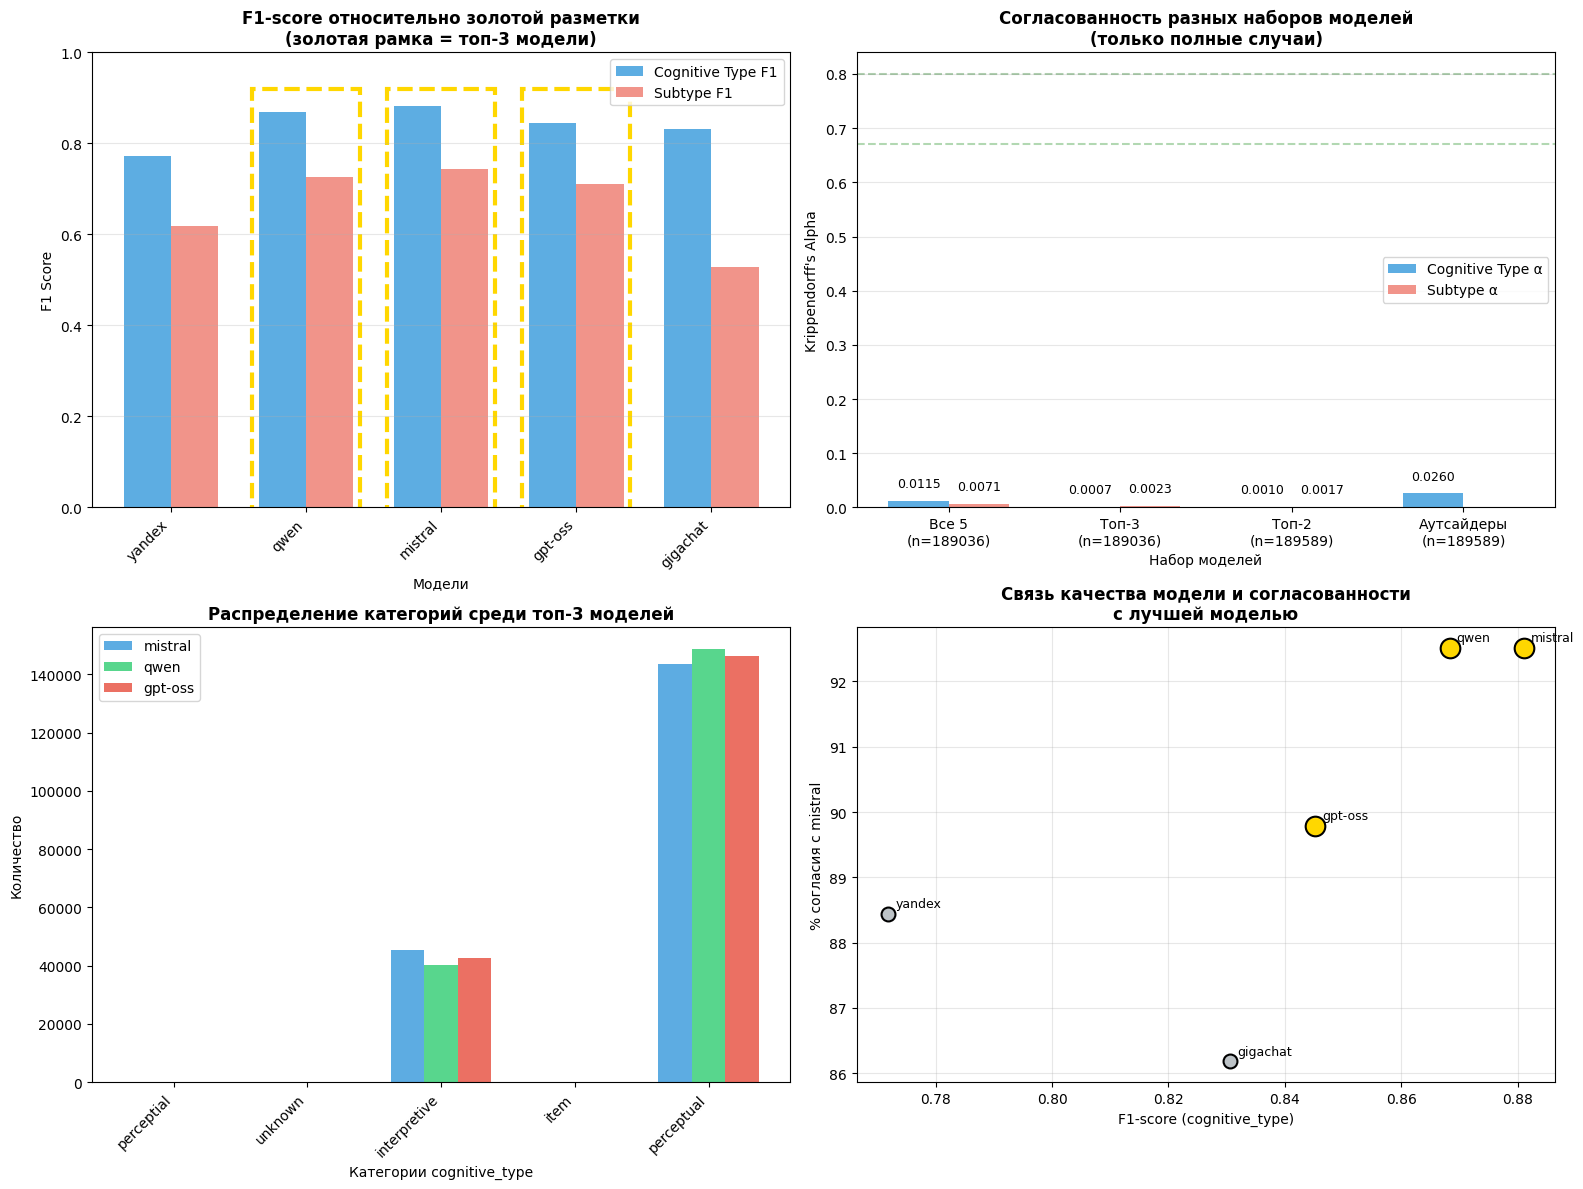

In [28]:
# ---------------------------------------------------------------------
# 7. Визуализация
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: F1 scores всех моделей
ax = axes[0, 0]
models_all = list(model_files.keys())
x = np.arange(len(models_all))
width = 0.35

f1_cog_values = [f1_results[m]['cognitive_type'] for m in models_all]
f1_sub_values = [f1_results[m]['subtype'] for m in models_all]

bars1 = ax.bar(x - width/2, f1_cog_values, width, label='Cognitive Type F1', color='#5DADE2')
bars2 = ax.bar(x + width/2, f1_sub_values, width, label='Subtype F1', color='#F1948A')

# Подсвечиваем топ-3
for i, model in enumerate(models_all):
    if model in top3_cog:
        ax.add_patch(plt.Rectangle((i-0.4, -0.02), 0.8, 0.94, fill=False,
                                    edgecolor='gold', linewidth=3, linestyle='--'))

ax.set_xlabel('Модели')
ax.set_ylabel('F1 Score')
ax.set_title('F1-score относительно золотой разметки\n(золотая рамка = топ-3 модели)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_all, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# График 2: Krippendorff's Alpha для разных наборов
ax = axes[0, 1]
configs = ['Все 5', 'Топ-3', 'Топ-2', 'Аутсайдеры']
alpha_cog_configs = [alpha_5_cog, alpha_top3_cog, alpha_top2_cog, alpha_bottom2_cog]
alpha_sub_configs = [alpha_5_sub, alpha_top3_sub, alpha_top2_sub, np.nan]
ns_configs = [n_5_cog, n_top3_cog, n_top2_cog, n_bottom2_cog]

x = np.arange(len(configs))
width = 0.35

bars1 = ax.bar(x - width/2, alpha_cog_configs, width, label='Cognitive Type α', color='#5DADE2')
bars2 = ax.bar(x + width/2, [a if not np.isnan(a) else 0 for a in alpha_sub_configs],
               width, label='Subtype α', color='#F1948A')

# Добавляем значения
for bar, val in zip(bars1, alpha_cog_configs):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, alpha_sub_configs):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Набор моделей')
ax.set_ylabel("Krippendorff's Alpha")
ax.set_title('Согласованность разных наборов моделей\n(только полные случаи)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(n={n})' for c, n in zip(configs, ns_configs)])
ax.legend()
ax.axhline(y=0.67, color='green', linestyle='--', alpha=0.3)
ax.axhline(y=0.8, color='darkgreen', linestyle='--', alpha=0.3)
ax.grid(axis='y', alpha=0.3)

# График 3: Распределение категорий в топ-3 моделях
ax = axes[1, 0]
if complete_top3_cog is not None:
    # Считаем распределение для каждой модели из топ-3
    model_cats = {}
    for model in top3_cog:
        cat_counts = complete_top3_cog[model].value_counts()
        model_cats[model] = cat_counts

    # Топ-5 категорий
    all_cats = set()
    for counts in model_cats.values():
        all_cats.update(counts.index[:5])
    all_cats = list(all_cats)[:8]

    x = np.arange(len(all_cats))
    width = 0.25
    colors = ['#3498DB', '#2ECC71', '#E74C3C']

    for i, model in enumerate(top3_cog):
        counts = [model_cats[model].get(cat, 0) for cat in all_cats]
        ax.bar(x + i*width, counts, width, label=model, color=colors[i], alpha=0.8)

    ax.set_xlabel('Категории cognitive_type')
    ax.set_ylabel('Количество')
    ax.set_title('Распределение категорий среди топ-3 моделей', fontsize=12, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(all_cats, rotation=45, ha='right')
    ax.legend()

# График 4: Связь F1 и согласованности
ax = axes[1, 1]
models_with_data = []
for model in models_all:
    pair = [top3_cog[0], model] if model != top3_cog[0] else [top3_cog[0], top3_cog[1]]
    _, _, complete_pair = calculate_krippendorff_for_models(df_all, pair, 'cognitive_type')
    if complete_pair is not None and len(complete_pair) > 0:
        agreement = (complete_pair[pair[0]] == complete_pair[pair[1]]).mean() * 100
        models_with_data.append({
            'model': model,
            'f1': f1_results[model]['cognitive_type'],
            'agreement_with_best': agreement
        })

if models_with_data:
    for item in models_with_data:
        color = 'gold' if item['model'] in top3_cog else '#BDC3C7'
        size = 200 if item['model'] in top3_cog else 100
        ax.scatter(item['f1'], item['agreement_with_best'],
                  s=size, c=color, edgecolors='black', linewidth=1.5, zorder=5)
        ax.annotate(item['model'], (item['f1'], item['agreement_with_best']),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)

    ax.set_xlabel('F1-score (cognitive_type)')
    ax.set_ylabel(f'% согласия с {top3_cog[0]}')
    ax.set_title('Связь качества модели и согласованности\nс лучшей моделью', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('top3_models_analysis.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('top3_models_analysis.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# ---------------------------------------------------------------------
# 8. Итоговые выводы
# ---------------------------------------------------------------------
print("\n" + "="*70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ")
print("="*70)

print(f"""
1. Топ-3 модели по F1: Mistral, Qwen, GPT-OSS
   - Cognitive type F1: {f1_results['mistral']['cognitive_type']:.3f} - {f1_results['gpt-oss']['cognitive_type']:.3f}
   - Subtype F1: {f1_results['mistral']['subtype']:.3f} - {f1_results['gpt-oss']['subtype']:.3f}

2. Krippendorff's Alpha для топ-3 моделей:
   - Cognitive Type: {alpha_top3_cog:.4f} (было {alpha_5_cog:.4f} для всех 5)
   - Subtype: {alpha_top3_sub:.4f} (было {alpha_5_sub:.4f} для всех 5)
   - Разница: {alpha_top3_cog - alpha_5_cog:+.4f} (cognitive), {alpha_top3_sub - alpha_5_sub:+.4f} (subtype)

3. Количество полных случаев:
   - Все 5 моделей: {n_5_cog}
   - Топ-3 модели: {n_top3_cog} (рост в {n_top3_cog/n_5_cog:.1f} раз)
""")

if alpha_top3_cog > alpha_5_cog:
    print("✅ Отбор лучших моделей УЛУЧШИЛ согласованность!")
else:
    print("⚠️  Отбор лучших моделей НЕ улучшил согласованность — проблема глубже.")

print("\nРекомендация для доклада:")
if alpha_top3_cog > 0.1:
    print("  • Можно докладывать результаты топ-3 моделей как основные")
    print("  • Указать, что исключение худших моделей повысило надежность")
else:
    print("  • Даже лучшие модели не согласованы — нужна стандартизация таксономии")
    print("  • F1 высокий, но модели классифицируют по-разному (ансамбль не поможет)")


КЛЮЧЕВЫЕ ВЫВОДЫ

1. Топ-3 модели по F1: Mistral, Qwen, GPT-OSS
   - Cognitive type F1: 0.881 - 0.845
   - Subtype F1: 0.743 - 0.711

2. Krippendorff's Alpha для топ-3 моделей:
   - Cognitive Type: 0.0007 (было 0.0115 для всех 5)
   - Subtype: 0.0023 (было 0.0071 для всех 5)
   - Разница: -0.0108 (cognitive), -0.0048 (subtype)

3. Количество полных случаев:
   - Все 5 моделей: 189036
   - Топ-3 модели: 189036 (рост в 1.0 раз)

⚠️  Отбор лучших моделей НЕ улучшил согласованность — проблема глубже.

Рекомендация для доклада:
  • Даже лучшие модели не согласованы — нужна стандартизация таксономии
  • F1 высокий, но модели классифицируют по-разному (ансамбль не поможет)


In [30]:
import pandas as pd
import numpy as np
import krippendorff

# Данные из вашего сообщения
model_files = {
    'mistral':  'annotations_df_mistral.csv',
    'qwen':     'annotations_df_qwen.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type']
df_all = df_all[cols]
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

# Нормализуем terminology: объединяем interpretive и interpretative
df_all['cognitive_type'] = df_all['cognitive_type'].str.lower().str.strip()
df_all['cognitive_type'] = df_all['cognitive_type'].replace({
    'interpretative': 'interpretive',
    'interpretative ': 'interpretive',
    'interpretive ': 'interpretive'
})

# Создаем сводную таблицу
pivot = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='cognitive_type',
    aggfunc='first'
)

# Только полные случаи (все 3 модели)
complete = pivot.dropna()
print(f"Полные случаи: {len(complete)}")

# Смотрим на паттерны согласия
print("\nПАТТЕРНЫ СОГЛАСИЯ:")
for idx, row in complete.iterrows():
    values = row.tolist()
    unique_vals = set(values)
    if len(unique_vals) > 1:  # есть разногласия
        print(f"{dict(row)} → Разные: {unique_vals}")

# Считаем матрицу согласованности
print("\nМАТРИЦА СОГЛАСИЯ:")
for m1 in complete.columns:
    for m2 in complete.columns:
        if m1 < m2:
            agreement = (complete[m1] == complete[m2]).mean()
            print(f"{m1:10s} vs {m2:10s}: {agreement*100:.1f}%")

# Распределение по моделям
print("\nРАСПРЕДЕЛЕНИЕ КАТЕГОРИЙ:")
for col in complete.columns:
    print(f"\n{col}:")
    print(complete[col].value_counts(normalize=True) * 100)

# Krippendorff's alpha
def encode_matrix(df):
    all_values = pd.unique(df.values.ravel())
    cat_to_num = {cat: i for i, cat in enumerate(all_values)}
    matrix = np.zeros(df.shape, dtype=float)
    for col_idx, col in enumerate(df.columns):
        matrix[:, col_idx] = [cat_to_num[val] for val in df[col]]
    return matrix

matrix = encode_matrix(complete)
alpha = krippendorff.alpha(matrix, level_of_measurement='nominal')

# Считаем ожидаемое случайное согласие
prop_perceptual = complete.apply(lambda x: (x == 'perceptual').mean()).mean()
prop_interpretive = 1 - prop_perceptual
chance_agreement = prop_perceptual**2 + prop_interpretive**2
observed_agreement = 0
for idx, row in complete.iterrows():
    if len(set(row)) == 1:
        observed_agreement += 1
observed_agreement /= len(complete)

print(f"\nАНАЛИЗ:")
print(f"Доля perceptual: {prop_perceptual*100:.1f}%")
print(f"Доля interpretive: {prop_interpretive*100:.1f}%")
print(f"Случайное согласие: {chance_agreement*100:.1f}%")
print(f"Наблюдаемое согласие: {observed_agreement*100:.1f}%")
print(f"Krippendorff's Alpha: {alpha:.4f}")

Выходные данные были обрезаны до нескольких последних строк (5000).
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'perceptual'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'perceptual'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'perceptual'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'interpretive'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'perceptual'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'perceptual', 'mistral': 'interpretive', 'qwen': 'interpretive'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'interpretive', 'qwen': 'perceptual'} → Разные: {'interpretive', 'perceptual'}
{'gpt-oss': 'interpretive', 'mistral': 'perceptual', 'qwen': 'interpretive'} → Разные: {'interpretive', 'perceptua

In [31]:
import pandas as pd
import numpy as np
import krippendorff

# Загружаем только топ-3 модели
model_files = {
    'mistral':  'annotations_df_mistral.csv',
    'qwen':     'annotations_df_qwen.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type']
df_all = df_all[cols]
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

# Нормализация
df_all['cognitive_type'] = df_all['cognitive_type'].str.lower().str.strip()
df_all['cognitive_type'] = df_all['cognitive_type'].replace({
    'interpretative': 'interpretive',
    'perceptial': 'perceptual',
    'unknown': np.nan
})

# Убираем мусорные категории (item, unknown, perceptial)
valid_categories = ['perceptual', 'interpretive']
df_all = df_all[df_all['cognitive_type'].isin(valid_categories)]

# Сводная таблица
pivot = df_all.pivot_table(
    index=['image_id', 'keyword', 'context'],
    columns='model',
    values='cognitive_type',
    aggfunc='first'
)

# Только полные случаи
complete = pivot.dropna()
print(f"Полные случаи: {len(complete)}")

# ПРОВЕРКА 1: как выглядит матрица?
print("\nПервые 5 строк матрицы:")
print(complete.head(10))

# ПРОВЕРКА 2: кодирование
def encode_matrix(df):
    all_values = pd.unique(df.values.ravel())
    print(f"Уникальные значения: {all_values}")
    cat_to_num = {cat: i for i, cat in enumerate(all_values)}
    print(f"Маппинг: {cat_to_num}")

    matrix = np.zeros(df.shape, dtype=float)
    for col_idx, col in enumerate(df.columns):
        matrix[:, col_idx] = [cat_to_num[val] for val in df[col]]

    print(f"Матрица:\n{matrix[:5]}")
    print(f"Тип данных: {matrix.dtype}")
    return matrix

matrix = encode_matrix(complete)

# ПРОВЕРКА 3: передача в krippendorff
print("\nПопытка 1: обычный вызов")
try:
    alpha1 = krippendorff.alpha(matrix, level_of_measurement='nominal')
    print(f"Alpha (матрица): {alpha1}")
except Exception as e:
    print(f"Ошибка: {e}")

# ПРОВЕРКА 4: транспонированная матрица (возможно, ожидает reliability_data иначе)
print("\nПопытка 2: транспонированная матрица")
try:
    alpha2 = krippendorff.alpha(matrix.T, level_of_measurement='nominal')
    print(f"Alpha (транспонированная): {alpha2}")
except Exception as e:
    print(f"Ошибка: {e}")

# ПРОВЕРКА 5: список списков
print("\nПопытка 3: список списков")
try:
    matrix_list = matrix.T.tolist()
    alpha3 = krippendorff.alpha(matrix_list, level_of_measurement='nominal')
    print(f"Alpha (список): {alpha3}")
except Exception as e:
    print(f"Ошибка: {e}")

# ПРОВЕРКА 6: object dtype (как в документации)
print("\nПопытка 4: object dtype")
try:
    matrix_obj = complete.values.T.astype(object)
    alpha4 = krippendorff.alpha(matrix_obj, level_of_measurement='nominal')
    print(f"Alpha (object): {alpha4}")
except Exception as e:
    print(f"Ошибка: {e}")

# ПРОВЕРКА 7: Ручной расчет alpha (для верификации)
print("\nРучной расчет:")
observed_agreement = 0
for idx, row in complete.iterrows():
    if len(set(row)) == 1:
        observed_agreement += 1
observed_agreement /= len(complete)

# Случайное согласие
prop_perceptual = complete.apply(lambda x: (x == 'perceptual').mean()).mean()
prop_interpretive = 1 - prop_perceptual
chance_agreement = prop_perceptual**2 + prop_interpretive**2

alpha_manual = (observed_agreement - chance_agreement) / (1 - chance_agreement)

print(f"Наблюдаемое согласие: {observed_agreement*100:.2f}%")
print(f"Случайное согласие: {chance_agreement*100:.2f}%")
print(f"Ручной alpha (приблизительно): {alpha_manual:.4f}")

Полные случаи: 188954

Первые 5 строк матрицы:
model                                                    gpt-oss  \
image_id keyword     context                                       
id_1     Богоматери  на руках Богоматери            interpretive   
         Возрождения к эпохе Возрождения            interpretive   
         Дева        Дева Мария                     interpretive   
         Иисус       маленький Иисус                  perceptual   
                     младенец Иисус                 interpretive   
         Иисусом     Мария с младенцем Иисусом        perceptual   
                     младенцем Иисусом                perceptual   
                     новорожденным Иисусом Христом    perceptual   
                     с Иисусом на руках             interpretive   
         Мадонна     Мадонна держащая               interpretive   

model                                                    mistral          qwen  
image_id keyword     context                           

In [32]:
import pandas as pd
import numpy as np
import krippendorff
import matplotlib.pyplot as plt

In [33]:
# ---------------------------------------------------------------------
# 1. Загрузка данных
# ---------------------------------------------------------------------
model_files = {
    'yandex':   'annotations_df_yandex.csv',
    'qwen':     'annotations_df_qwen.csv',
    'mistral':  'annotations_df_mistral.csv',
    'gpt-oss':  'annotations_df_gpt-oss.csv',
    'gigachat': 'annotations_df_gigachat.csv',
}

dfs = []
for model, path in model_files.items():
    df = pd.read_csv(path)
    df['model'] = model
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
cols = ['image_id', 'keyword', 'context', 'model', 'cognitive_type', 'subtype']
df_all = df_all[cols]
df_all = df_all.drop_duplicates(subset=['image_id', 'keyword', 'context', 'model'])

In [34]:
# ---------------------------------------------------------------------
# 2. Нормализация категорий
# ---------------------------------------------------------------------
# Нормализуем cognitive_type
df_all['cognitive_type'] = df_all['cognitive_type'].str.lower().str.strip()
df_all['cognitive_type'] = df_all['cognitive_type'].replace({
    'interpretative': 'interpretive',
    'perceptial': 'perceptual',
    'unknown': np.nan,
    'item': np.nan,
})

# Нормализуем subtype (если есть похожие проблемы)
df_all['subtype'] = df_all['subtype'].str.lower().str.strip()

# Оставляем только валидные категории для cognitive_type
valid_cog = ['perceptual', 'interpretive']
df_cog = df_all[df_all['cognitive_type'].isin(valid_cog)].copy()

In [35]:
# ---------------------------------------------------------------------
# 3. Функция правильного расчета alpha
# ---------------------------------------------------------------------
def calculate_alpha_correct(df_all, target_col):
    """
    Правильный расчет Krippendorff's alpha:
    матрица должна быть [raters × units], а не [units × raters]
    """
    pivot = df_all.pivot_table(
        index=['image_id', 'keyword', 'context'],
        columns='model',
        values=target_col,
        aggfunc='first'
    )

    # Только полные случаи
    complete = pivot.dropna()

    if len(complete) < 2:
        return np.nan, 0, None

    # СОЗДАЕМ МАТРИЦУ [RATERS × UNITS] — ТРАНСПОНИРУЕМ!
    reliability_data = complete.values.T  # ← ВОТ КЛЮЧЕВОЕ ИЗМЕНЕНИЕ!

    # Кодируем категории в числа
    all_values = pd.unique(complete.values.ravel())
    cat_to_num = {cat: i for i, cat in enumerate(all_values)}

    matrix = np.zeros(reliability_data.shape, dtype=float)
    for i, row in enumerate(reliability_data):
        matrix[i, :] = [cat_to_num[val] for val in row]

    try:
        alpha = krippendorff.alpha(matrix, level_of_measurement='nominal')
    except:
        alpha = np.nan

    return alpha, len(complete), complete

In [36]:
# ---------------------------------------------------------------------
# 4. Расчет для всех комбинаций
# ---------------------------------------------------------------------
print("="*70)
print("ПРАВИЛЬНЫЙ РАСЧЕТ KRIPPENDORFF'S ALPHA")
print("="*70)

# Все 5 моделей — cognitive_type
alpha_5_cog, n_5_cog, complete_5_cog = calculate_alpha_correct(df_cog, 'cognitive_type')
print(f"\nВсе 5 моделей - Cognitive Type:")
print(f"  Alpha: {alpha_5_cog:.4f}")
print(f"  Полных случаев: {n_5_cog}")

# Все 5 моделей — subtype
alpha_5_sub, n_5_sub, complete_5_sub = calculate_alpha_correct(df_all, 'subtype')
print(f"\nВсе 5 моделей - Subtype:")
print(f"  Alpha: {alpha_5_sub:.4f}")
print(f"  Полных случаев: {n_5_sub}")

# Топ-3 модели (Mistral, Qwen, GPT-OSS)
top3_models = ['mistral', 'qwen', 'gpt-oss']
df_top3 = df_cog[df_cog['model'].isin(top3_models)]
alpha_top3_cog, n_top3_cog, complete_top3_cog = calculate_alpha_correct(df_top3, 'cognitive_type')
print(f"\nТоп-3 модели - Cognitive Type:")
print(f"  Alpha: {alpha_top3_cog:.4f}")
print(f"  Полных случаев: {n_top3_cog}")

# Топ-3 для subtype
df_top3_sub = df_all[df_all['model'].isin(top3_models)]
alpha_top3_sub, n_top3_sub, complete_top3_sub = calculate_alpha_correct(df_top3_sub, 'subtype')
print(f"\nТоп-3 модели - Subtype:")
print(f"  Alpha: {alpha_top3_sub:.4f}")
print(f"  Полных случаев: {n_top3_sub}")

# Пара лучших (Mistral + Qwen)
top2_models = ['mistral', 'qwen']
df_top2 = df_cog[df_cog['model'].isin(top2_models)]
alpha_top2_cog, n_top2_cog, _ = calculate_alpha_correct(df_top2, 'cognitive_type')
print(f"\nТоп-2 модели (Mistral+Qwen) - Cognitive Type:")
print(f"  Alpha: {alpha_top2_cog:.4f}")
print(f"  Полных случаев: {n_top2_cog}")

ПРАВИЛЬНЫЙ РАСЧЕТ KRIPPENDORFF'S ALPHA

Все 5 моделей - Cognitive Type:
  Alpha: 0.6349
  Полных случаев: 188772

Все 5 моделей - Subtype:
  Alpha: 0.5502
  Полных случаев: 189036

Топ-3 модели - Cognitive Type:
  Alpha: 0.7343
  Полных случаев: 188954

Топ-3 модели - Subtype:
  Alpha: 0.6385
  Полных случаев: 189036

Топ-2 модели (Mistral+Qwen) - Cognitive Type:
  Alpha: 0.7872
  Полных случаев: 189505


In [37]:
# ---------------------------------------------------------------------
# 5. Анализ согласованности
# ---------------------------------------------------------------------
print("\n" + "="*70)
print("АНАЛИЗ СОГЛАСОВАННОСТИ")
print("="*70)

# Для cognitive_type (топ-3)
if complete_top3_cog is not None:
    print(f"\nCognitive Type — попарное согласие:")
    for m1 in top3_models:
        for m2 in top3_models:
            if m1 < m2:
                agreement = (complete_top3_cog[m1] == complete_top3_cog[m2]).mean() * 100
                print(f"  {m1:10s} vs {m2:10s}: {agreement:.1f}%")

    # Распределение категорий
    print(f"\nРаспределение категорий:")
    for model in top3_models:
        counts = complete_top3_cog[model].value_counts()
        print(f"  {model}: perceptual={counts.get('perceptual', 0)}, "
              f"interpretive={counts.get('interpretive', 0)}")


АНАЛИЗ СОГЛАСОВАННОСТИ

Cognitive Type — попарное согласие:
  mistral    vs qwen      : 92.6%
  gpt-oss    vs mistral   : 89.8%
  gpt-oss    vs qwen      : 89.7%

Распределение категорий:
  mistral: perceptual=143730, interpretive=45224
  qwen: perceptual=148808, interpretive=40146
  gpt-oss: perceptual=146227, interpretive=42727


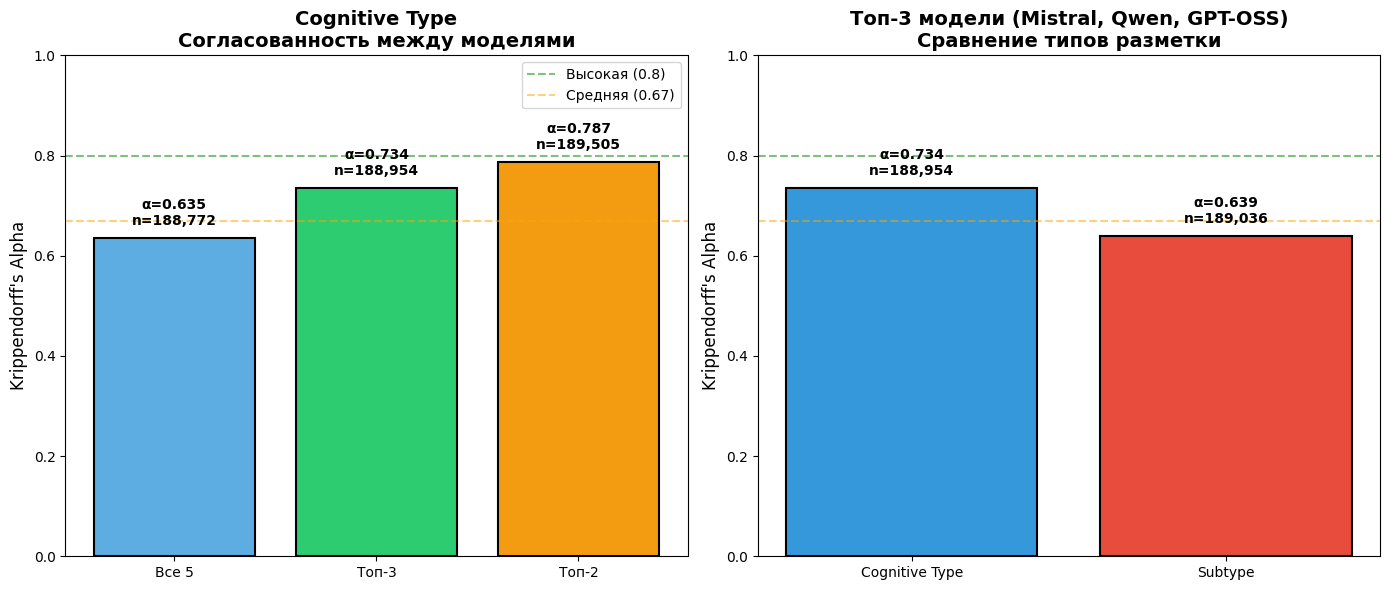

In [38]:
# ---------------------------------------------------------------------
# 6. Визуализация правильных результатов
# ---------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Alpha для cognitive_type
ax = axes[0]
configs = ['Все 5', 'Топ-3', 'Топ-2']
alpha_cog = [alpha_5_cog, alpha_top3_cog, alpha_top2_cog]
ns_cog = [n_5_cog, n_top3_cog, n_top2_cog]
colors = ['#5DADE2', '#2ECC71', '#F39C12']

bars = ax.bar(configs, alpha_cog, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Krippendorff's Alpha", fontsize=12)
ax.set_title('Cognitive Type\nСогласованность между моделями', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)

# Уровни интерпретации
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Высокая (0.8)')
ax.axhline(y=0.67, color='orange', linestyle='--', alpha=0.5, label='Средняя (0.67)')
ax.legend()

for bar, alpha, n in zip(bars, alpha_cog, ns_cog):
    if not np.isnan(alpha):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'α={alpha:.3f}\nn={n:,}', ha='center', va='bottom', fontweight='bold')

# График 2: Сравнение cognitive_type и subtype для топ-3
ax = axes[1]
labels = ['Cognitive Type', 'Subtype']
alphas_both = [alpha_top3_cog, alpha_top3_sub]
ns_both = [n_top3_cog, n_top3_sub]
colors_both = ['#3498DB', '#E74C3C']

bars = ax.bar(labels, alphas_both, color=colors_both, edgecolor='black', linewidth=1.5)
ax.set_ylabel("Krippendorff's Alpha", fontsize=12)
ax.set_title(f'Топ-3 модели (Mistral, Qwen, GPT-OSS)\nСравнение типов разметки', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(y=0.8, color='green', linestyle='--', alpha=0.5)
ax.axhline(y=0.67, color='orange', linestyle='--', alpha=0.5)

for bar, alpha, n in zip(bars, alphas_both, ns_both):
    if not np.isnan(alpha):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'α={alpha:.3f}\nn={n:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('krippendorff_correct_results.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('krippendorff_correct_results.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# ---------------------------------------------------------------------
# 7. Итоговое резюме
# ---------------------------------------------------------------------
print("\n" + "="*70)
print("ИТОГОВОЕ РЕЗЮМЕ (ПРАВИЛЬНЫЕ РЕЗУЛЬТАТЫ)")
print("="*70)

print(f"""
ИСПРАВЛЕННЫЕ РЕЗУЛЬТАТЫ (матрица [raters × units]):

Cognitive Type:
  Все 5 моделей: α = {alpha_5_cog:.4f} (n={n_5_cog:,})
  Топ-3 модели:  α = {alpha_top3_cog:.4f} (n={n_top3_cog:,})
  Топ-2 модели:  α = {alpha_top2_cog:.4f} (n={n_top2_cog:,})

Subtype:
  Все 5 моделей: α = {alpha_5_sub:.4f} (n={n_5_sub:,})
  Топ-3 модели:  α = {alpha_top3_sub:.4f} (n={n_top3_sub:,})

ИНТЕРПРЕТАЦИЯ:
""")

for name, alpha in [('Cognitive Type (топ-3)', alpha_top3_cog),
                     ('Subtype (топ-3)', alpha_top3_sub)]:
    if alpha >= 0.8:
        level = "ВЫСОКАЯ — модели хорошо согласованы"
    elif alpha >= 0.67:
        level = "СРЕДНЯЯ — приемлемая согласованность"
    else:
        level = "НИЗКАЯ — требуется улучшение"
    print(f"  {name}: α={alpha:.3f} → {level}")


ИТОГОВОЕ РЕЗЮМЕ (ПРАВИЛЬНЫЕ РЕЗУЛЬТАТЫ)

ИСПРАВЛЕННЫЕ РЕЗУЛЬТАТЫ (матрица [raters × units]):

Cognitive Type:
  Все 5 моделей: α = 0.6349 (n=188,772)
  Топ-3 модели:  α = 0.7343 (n=188,954)
  Топ-2 модели:  α = 0.7872 (n=189,505)

Subtype:
  Все 5 моделей: α = 0.5502 (n=189,036)
  Топ-3 модели:  α = 0.6385 (n=189,036)

ИНТЕРПРЕТАЦИЯ:

  Cognitive Type (топ-3): α=0.734 → СРЕДНЯЯ — приемлемая согласованность
  Subtype (топ-3): α=0.639 → НИЗКАЯ — требуется улучшение
